# Border Spillover Risk in Armed Conflict

## A geospatial risk-screening framework for West Africa, with a comparative note on Colombia-Venezuela

**Research question:** How do armed groups use borderlands to expand operational reach, and which indicators can help identify frontier zones at risk of spillover?


## Introduction

On May 11, 2025, Ansaroul Islam, a Jama’at Nusrat al-Islam wal-Muslimin (JNIM)-affiliated group, launched large-scale attacks against the town of Djibo, Burkina Faso, near the border with Mali, taking control of the town for several days. Dozens of civilians, soldiers, and paramilitary personnel were abducted and killed, and government infrastructure was destroyed. Only 2 days later, JNIM carried out a similar attack in Diapaga, 500 kilometers away from Djibo. Likewise, they seized the town and caused widespread destruction, overwhelming state defenses before any effective action could be taken. A few months before, in January 2025, 200 combatants from the Ejército de Liberación Nacional (ELN) crossed from Venezuela to Catatumbo, Colombia, to launch a coordinated attack against FARC dissidents. More than 100 people were killed and around 50,000 were displaced.

Across both contexts, borderlands emerge as enabling environments for armed groups. The recent Global Terrorism Index (GTI) identifies borderlands as a nexus of terrorist activity. According to the report, nearly 66% of terrorist attacks occurred within 100 km of an international border, with 40% taking place within only 50 kilometers, between 2007 and 2025. This pattern reflects traditional challenges that these territories provide to state forces. Borders are usually drawn along mountain ranges, dense forests, and bodies of water, which undermine state governance and facilitate exploitation for terrorist groups and organized crime to recruit, train, and control territory. An exacerbating factor is weak coordination between neighbouring states to address cross-border threats.


**Opening case sources:** Human Rights Watch on [Djibo](https://www.hrw.org/news/2025/09/15/burkina-faso-islamist-armed-groups-massacre-civilians), African Security Analysis on [Diapaga](https://www.africansecurityanalysis.org/updates/attack-on-diapaga-base-burkina-faso-may-13-2025), Human Rights Watch on [Catatumbo](https://www.hrw.org/news/2025/03/26/colombia-armed-groups-batter-border-region), and the [Global Terrorism Index 2026](https://www.visionofhumanity.org/wp-content/uploads/2026/03/Global-Terrorism-Index-2026-Report.pdf).


## Analytical Contribution

To systematically identify frontier zones where these conditions converge, this analysis develops the **Border Spillover Risk-Screening Framework**: a geospatial tool that operationalizes observable preconditions of spillover, including where violence is active, intensifying, and structured around geographic or infrastructural features that armed groups can exploit.

The framework comprises two core indices:

- **Border Militancy Exposure Index:** captures where armed group activity is already consolidated along a frontier, combining recent violence, fatality levels, escalation trends, border proximity, and actor involvement.
- **Coastal Spillover Risk Index:** captures where expansion signals toward adjacent coastal states are emerging, incorporating violence indicators alongside road corridor access, protected-area proximity, and the share of activity occurring on the receiving state's side of the border.

Together, these indices function as a screening tool, not a predictive model.


## Data and Method

The framework draws on ACLED event-level data covering January 1, 2018 to May 21, 2025 across eight West African countries and the Colombia-Venezuela border region, based on the local exports used in this project. Events were filtered by actor presence, retaining only incidents where named jihadist or hybrid armed groups appeared in any actor field, and restricted to **Battles**, **Explosions/Remote violence**, and **Violence against civilians**.

Border geometries were sourced from Natural Earth to calculate event-to-border distances and assign frontier zones. Operational-geography indicators were derived from OpenStreetMap/Geofabrik major-road and protected-area layers. Each index normalizes its indicators using min-max scaling and aggregates them into a composite score through a weighted sum, producing four risk tiers: **Low**, **Moderate**, **High**, and **Severe**.

Two limitations matter for interpretation: the actor-based filter may undercount activity by affiliated groups not explicitly labeled in ACLED, and min-max normalization is sensitive to outliers. The scores should therefore be read as structured screening outputs rather than forecasts.


In [ ]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

KNOWN_PROJECT_ROOTS = [
    Path('/Users/lisianealves/Documents/Codex/2026-05-20/Borderland Spillover'),
    Path('/Users/lisianealves/Documents/Codex/2026-05-20/quero-fazer-um-projeto-de-an'),
]

def has_outputs(path):
    return (path / 'outputs' / 'tables').exists() and (path / 'outputs' / 'maps').exists()

def find_project_root():
    # Works whether Jupyter starts in the repo root, inside notebooks/, or elsewhere.
    candidates = [Path.cwd(), *Path.cwd().parents, *KNOWN_PROJECT_ROOTS]
    for candidate in candidates:
        if has_outputs(candidate):
            return candidate
    checked = '\n'.join(str(candidate) for candidate in candidates)
    raise FileNotFoundError(
        'Could not find outputs/tables and outputs/maps. Checked these paths:\n' + checked
    )

PROJECT_ROOT = find_project_root()
TABLES = PROJECT_ROOT / 'outputs' / 'tables'
MAPS = PROJECT_ROOT / 'outputs' / 'maps'
CHARTS = PROJECT_ROOT / 'outputs' / 'charts'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

print(f'Project root: {PROJECT_ROOT}')


## 1. Border Proximity in West Africa

The first step is to test whether jihadist and militant events in the West Africa dataset cluster near international land borders. Coastlines are excluded from the border-distance calculation, so this measures distance to shared land borders only.


In [ ]:
border_bands = pd.read_csv(TABLES / 'jihadist_events_by_border_band.csv')
border_bands['share_events'] = border_bands['events'] / border_bands['events'].sum()
border_bands['share_fatalities'] = border_bands['fatalities'] / border_bands['fatalities'].sum()
border_bands

In [ ]:
within_100 = border_bands.loc[border_bands['border_band'].isin(['0-25 km', '25-50 km', '50-100 km']), 'events'].sum()
total_events = border_bands['events'].sum()
within_100_share = within_100 / total_events
print(f'Events within 100 km of a land border: {within_100:,} / {total_events:,} ({within_100_share:.1%})')

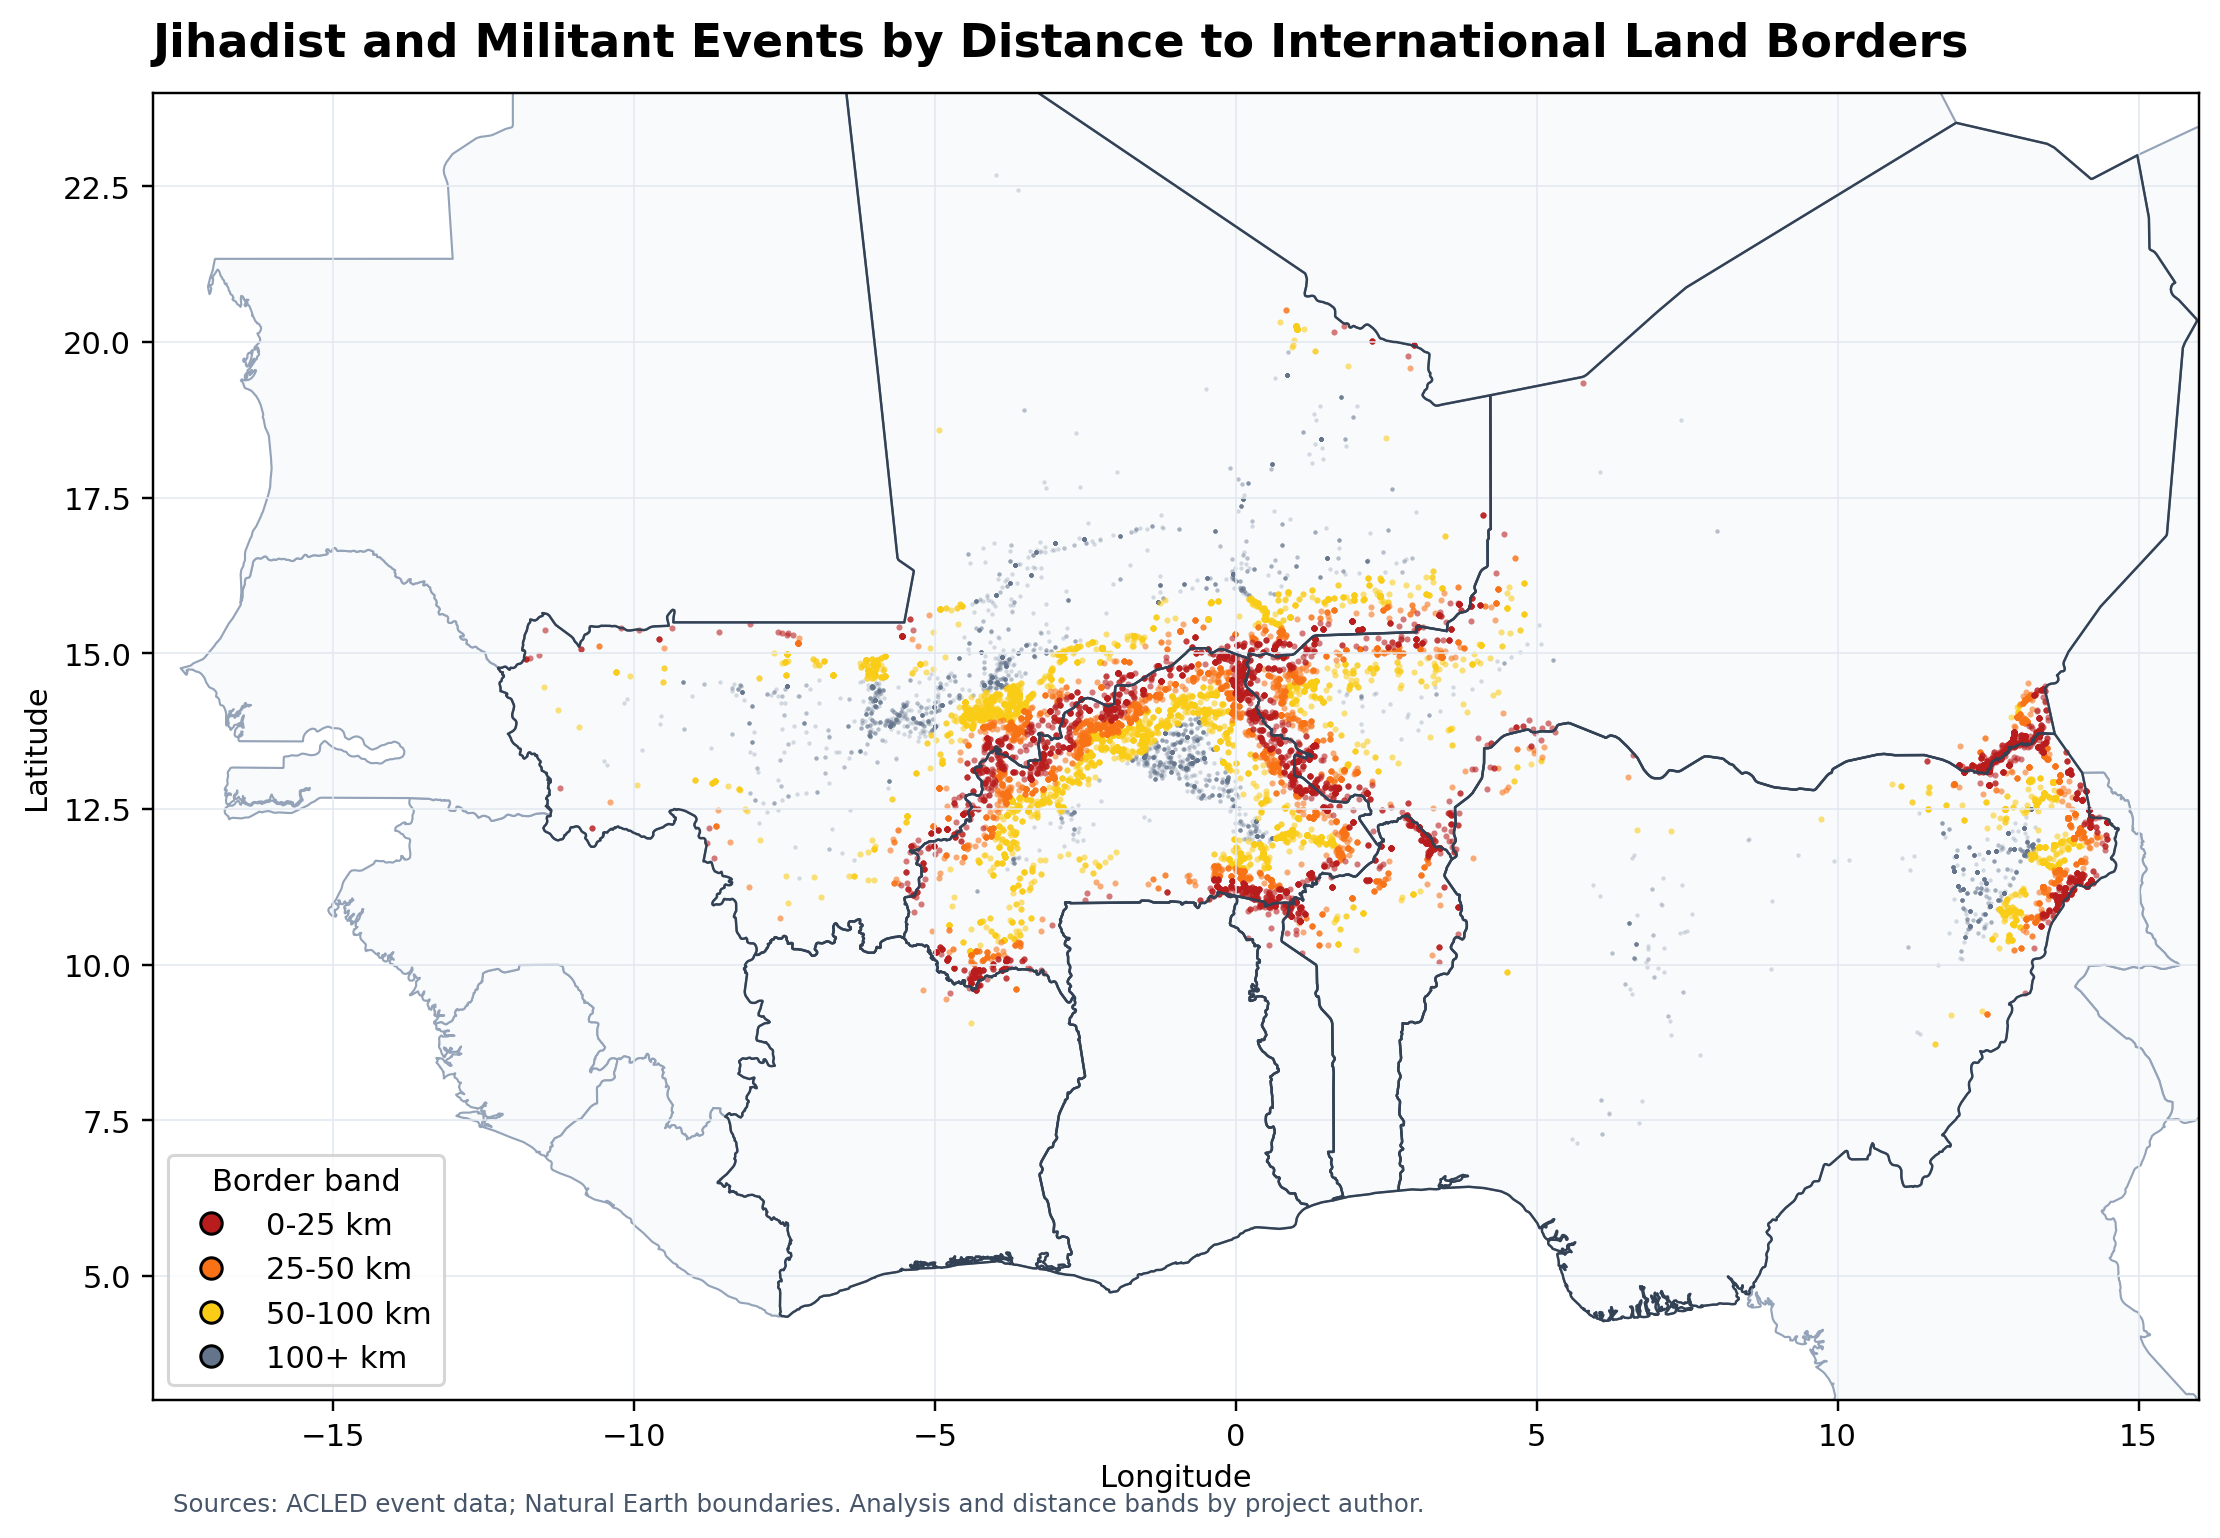

In [2]:
from IPython.display import Image, display
display(Image('outputs/maps/west_africa_events_by_border_band.png'));

**Interpretation.** The border-band results support the GTI-inspired starting premise: a large majority of filtered jihadist and militant events occur within 100 km of an international land border. But this alone is not the project's contribution. The more useful risk question is which border segments matter most and why.


## 2. From Border Proximity to Risk Screening

The project builds two related West Africa indices:

- **Border Militancy Exposure Index:** where borderland violence is already concentrated.
- **Coastal Spillover Risk Index v2:** where observed indicators suggest potential Sahel-to-coastal expansion.

The second index is the main product because it is closer to a risk-consulting question: where should analysts watch for spillover next?


In [ ]:
coastal = pd.read_csv(TABLES / 'coastal_spillover_risk_index_v2.csv')
coastal_display = coastal[[
    'border_dyad',
    'coastal_spillover_risk_score_v2',
    'risk_level',
    'evidence_confidence',
    'recent_events',
    'pct_within_25km_protected_area',
    'pct_within_10km_major_road',
]]
coastal_display

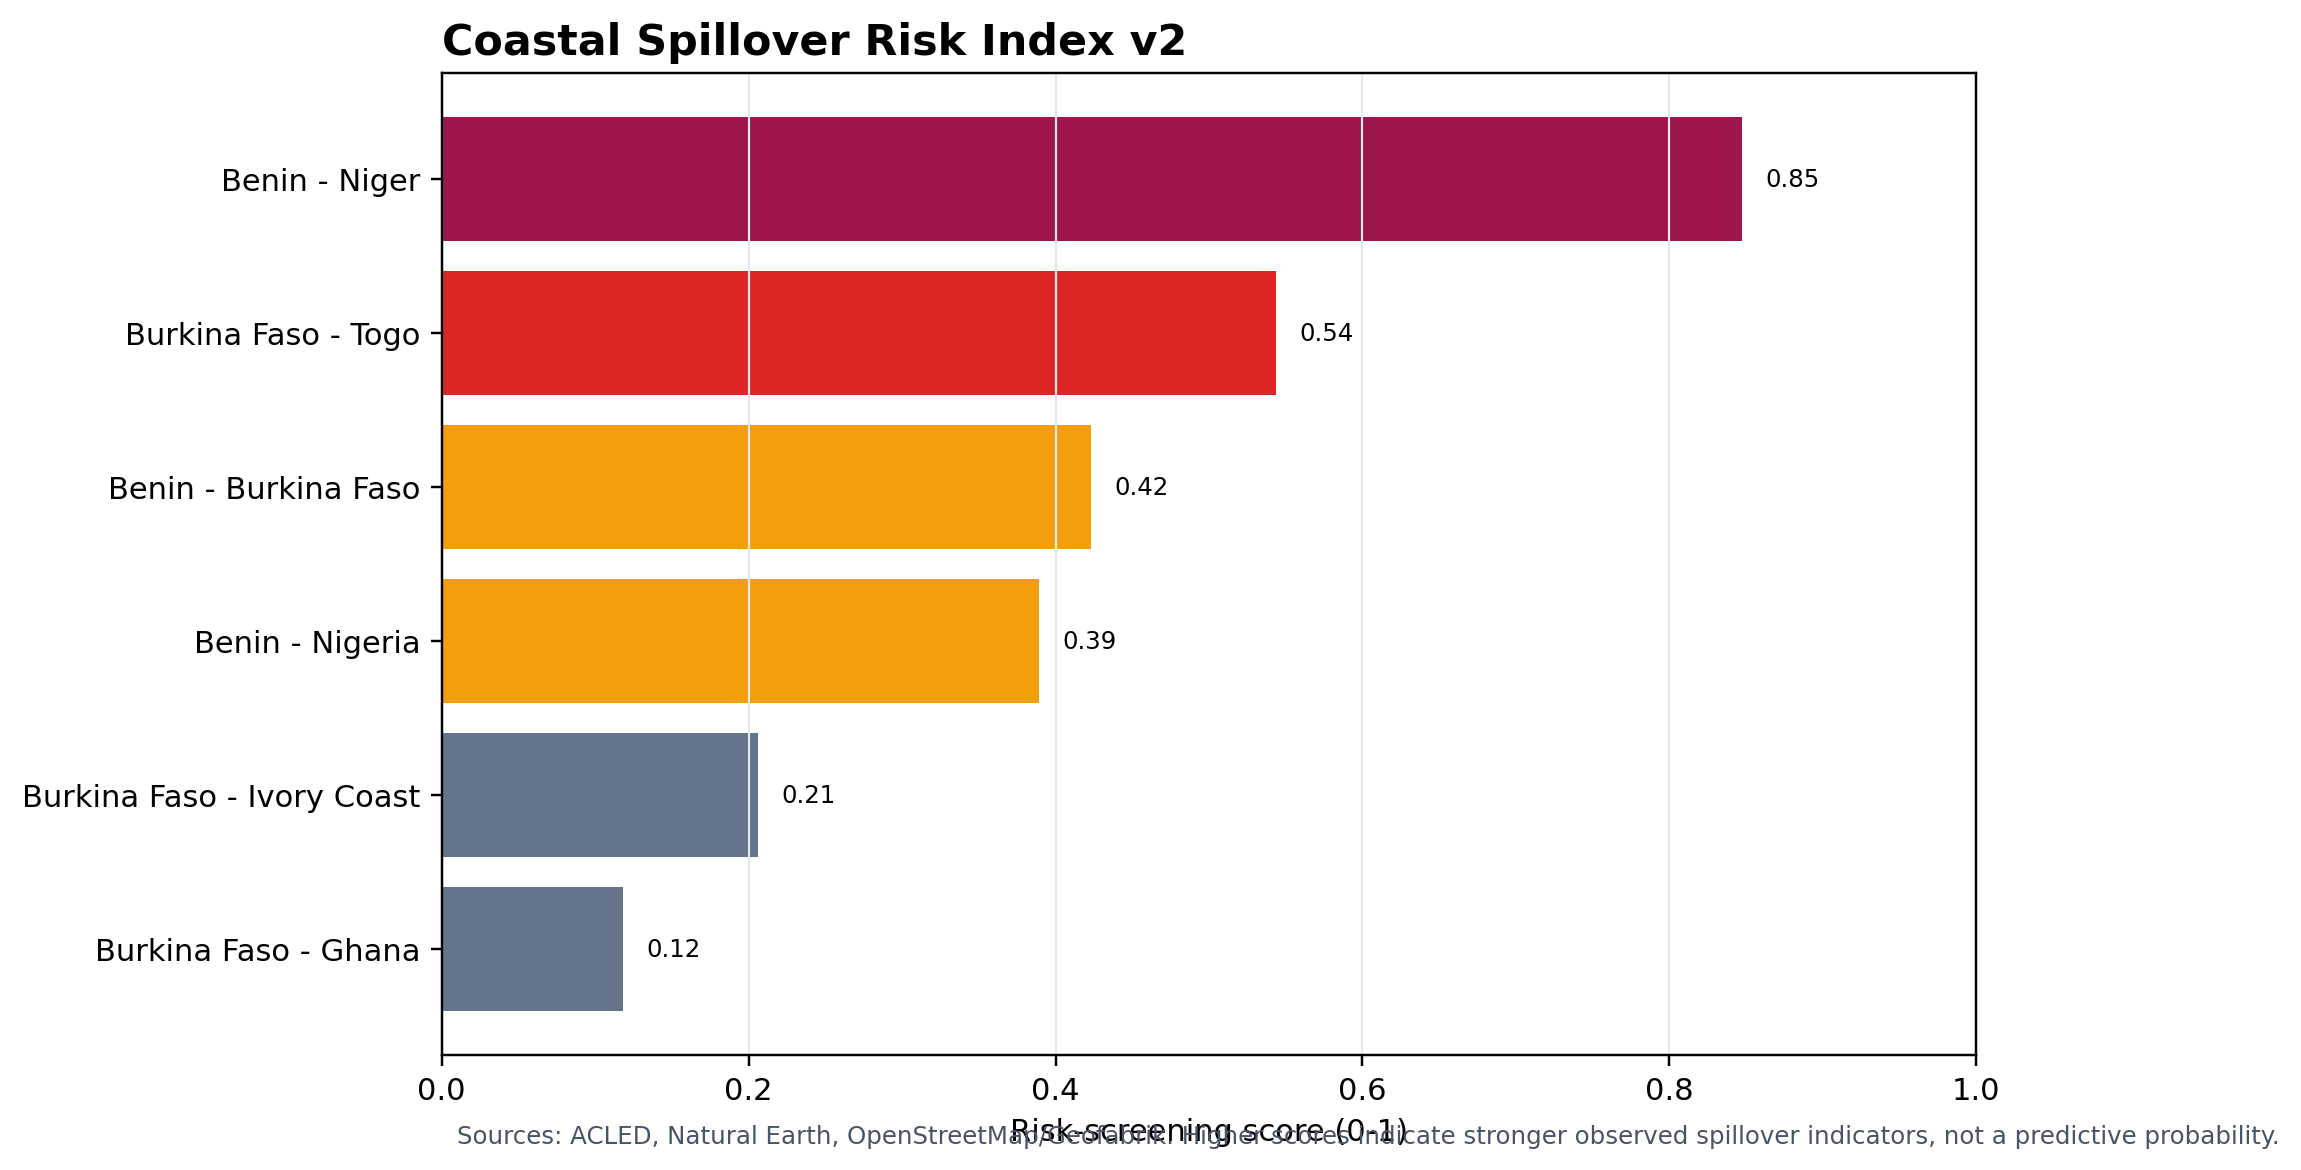

In [3]:
from IPython.display import Image, display
display(Image('outputs/charts/coastal_spillover_risk_index_v2.png'));

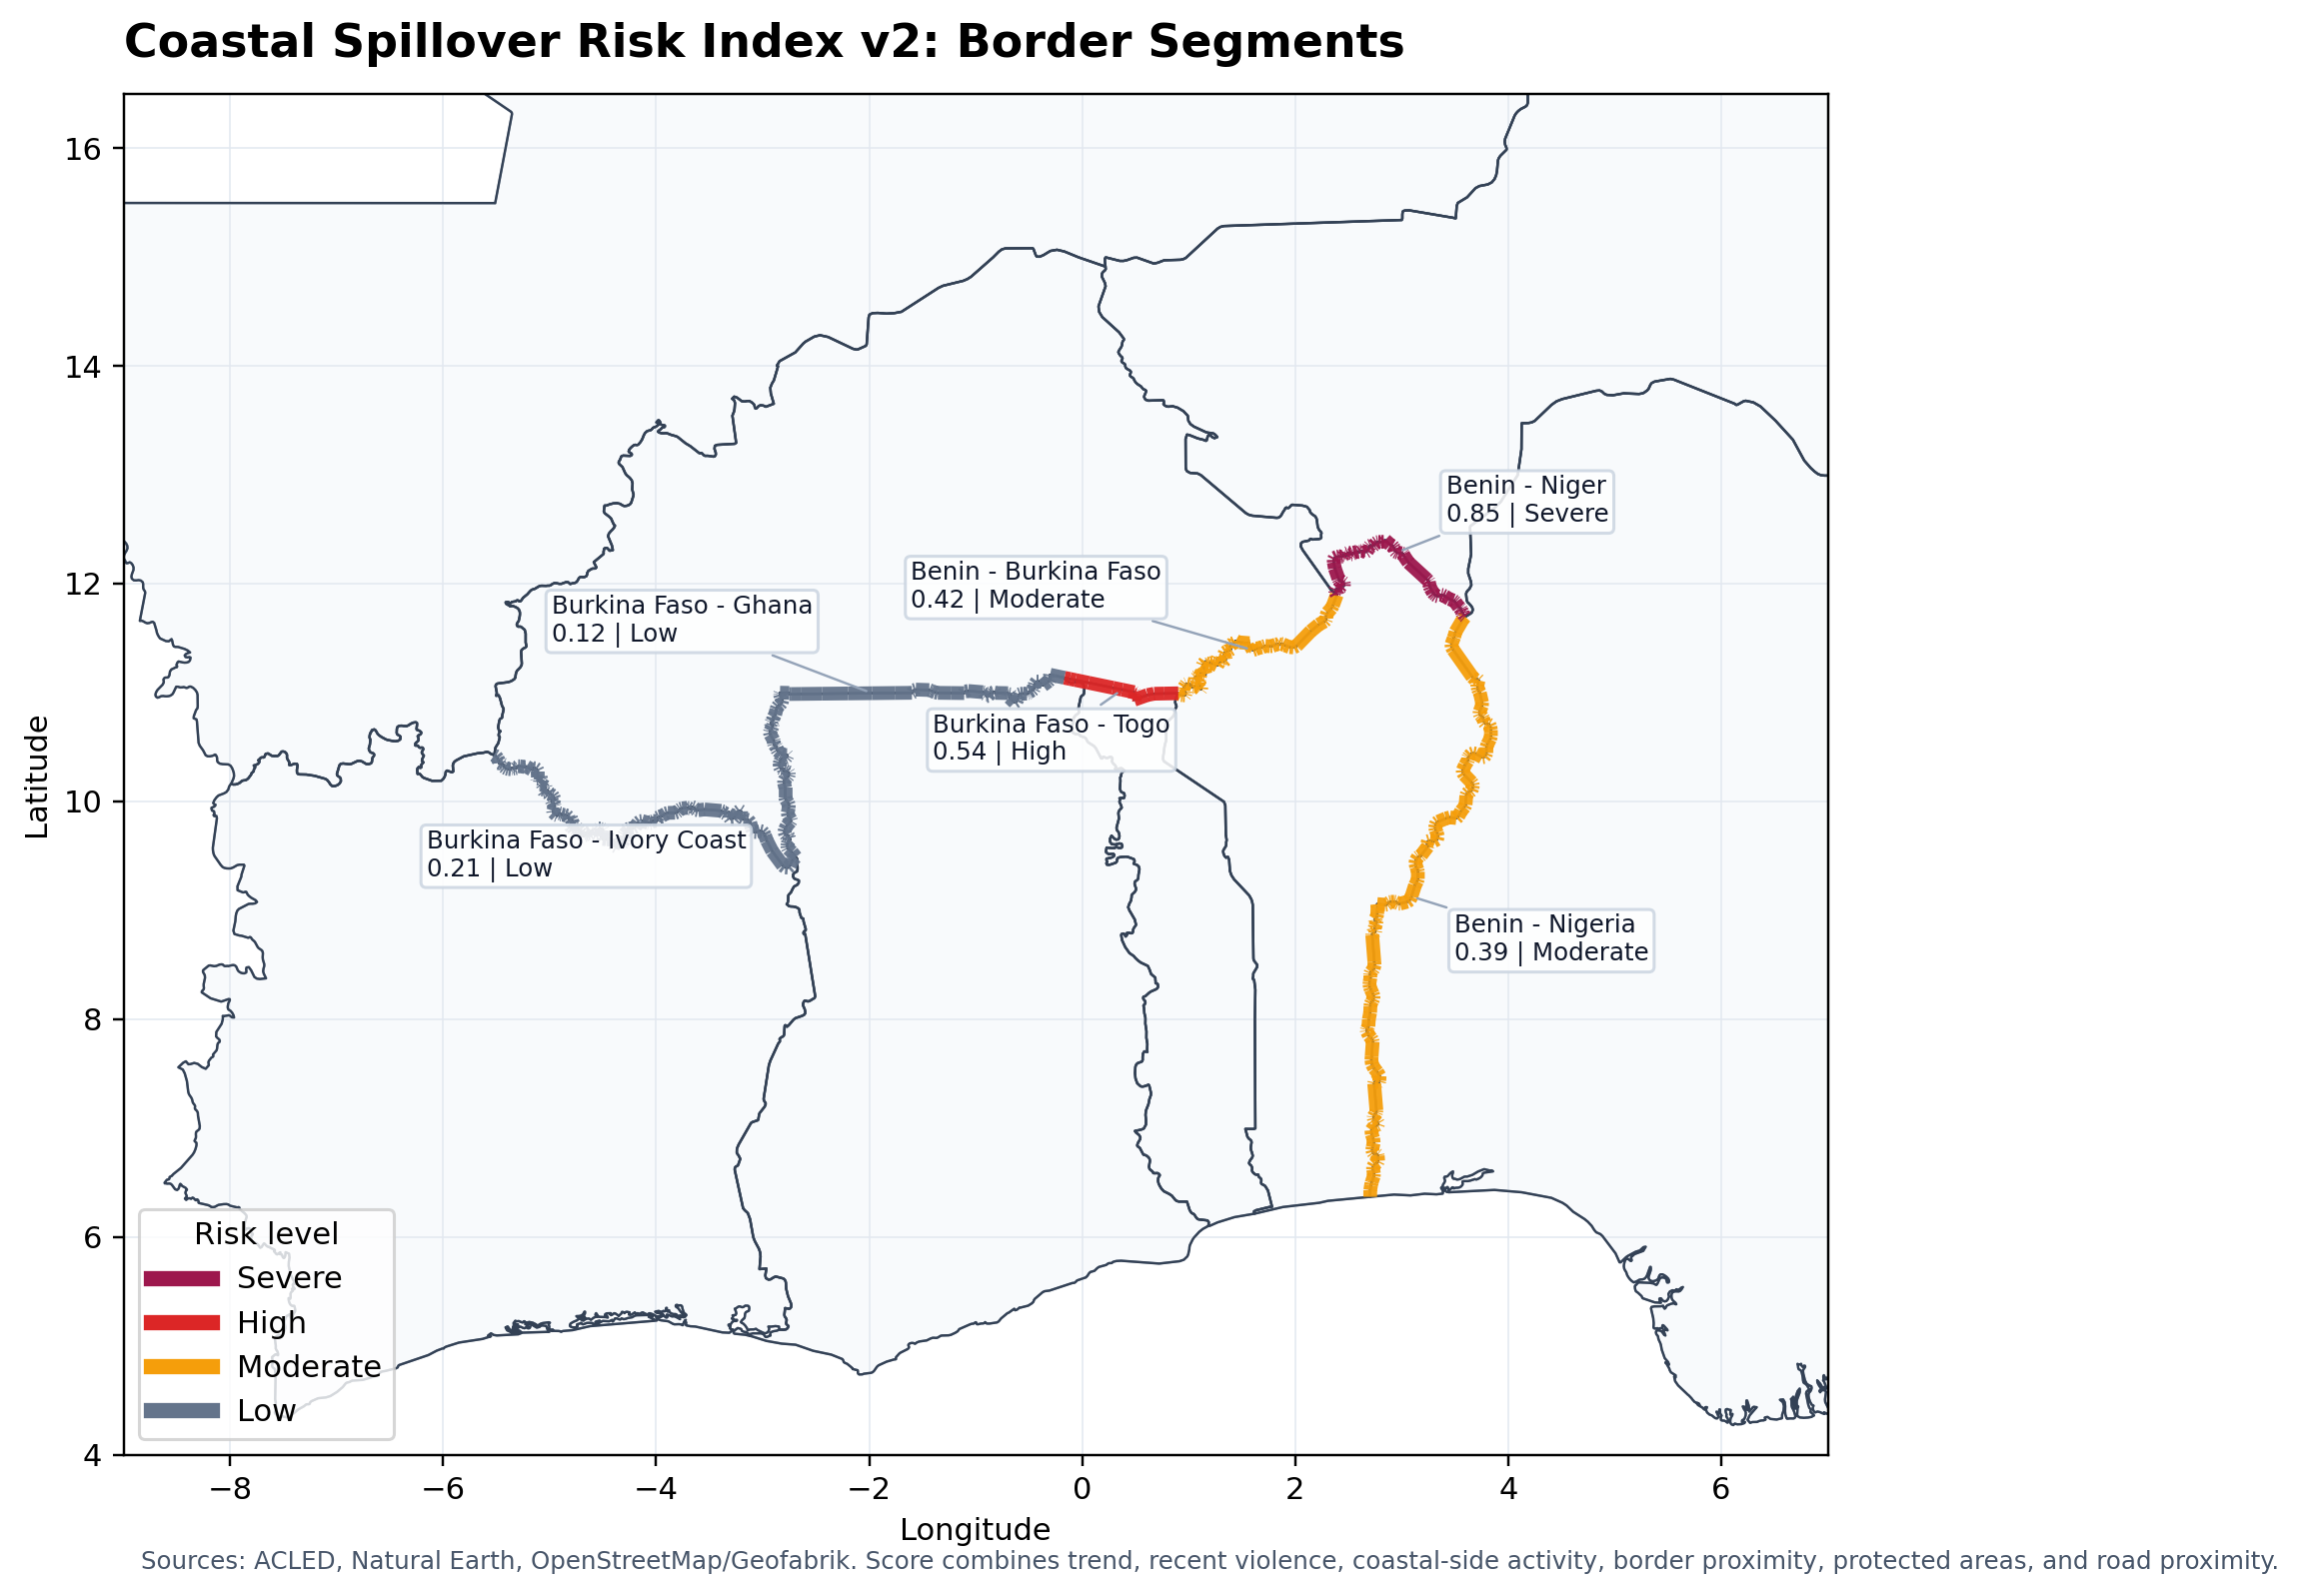

In [7]:
from IPython.display import Image, display
display(Image('outputs/maps/west_africa_coastal_spillover_index_v2.png'));

**Interpretation.** Benin-Niger is the strongest spillover signal in the V2 index. Burkina Faso-Togo also ranks high, driven by recent event volume and border proximity. Benin-Burkina Faso sits in the moderate range but has high evidence confidence and a stronger protected-area signal than most other coastal-facing dyads.


## 3. Operational Geography

Operational geography helps move the analysis from "events near borders" to "why these frontier zones may be useful to armed groups." The V2 index uses two practical proxies:

- proximity to protected areas;
- proximity to major road corridors.

Protected-area proximity is treated as a stronger signal than road proximity because ACLED events are often geocoded to settlements, and settlements are frequently located near roads.


In [ ]:
opgeo = pd.read_csv(TABLES / 'west_africa_operational_geography_by_border_dyad.csv')
opgeo_public = opgeo[opgeo['border_dyad'].isin(coastal['border_dyad'])].copy()
opgeo_public[[
    'border_dyad',
    'events',
    'operational_geo_events',
    'pct_within_10km_major_road',
    'pct_within_25km_protected_area',
    'median_distance_to_major_road_km',
    'median_distance_to_protected_area_km',
]].sort_values('pct_within_25km_protected_area', ascending=False)

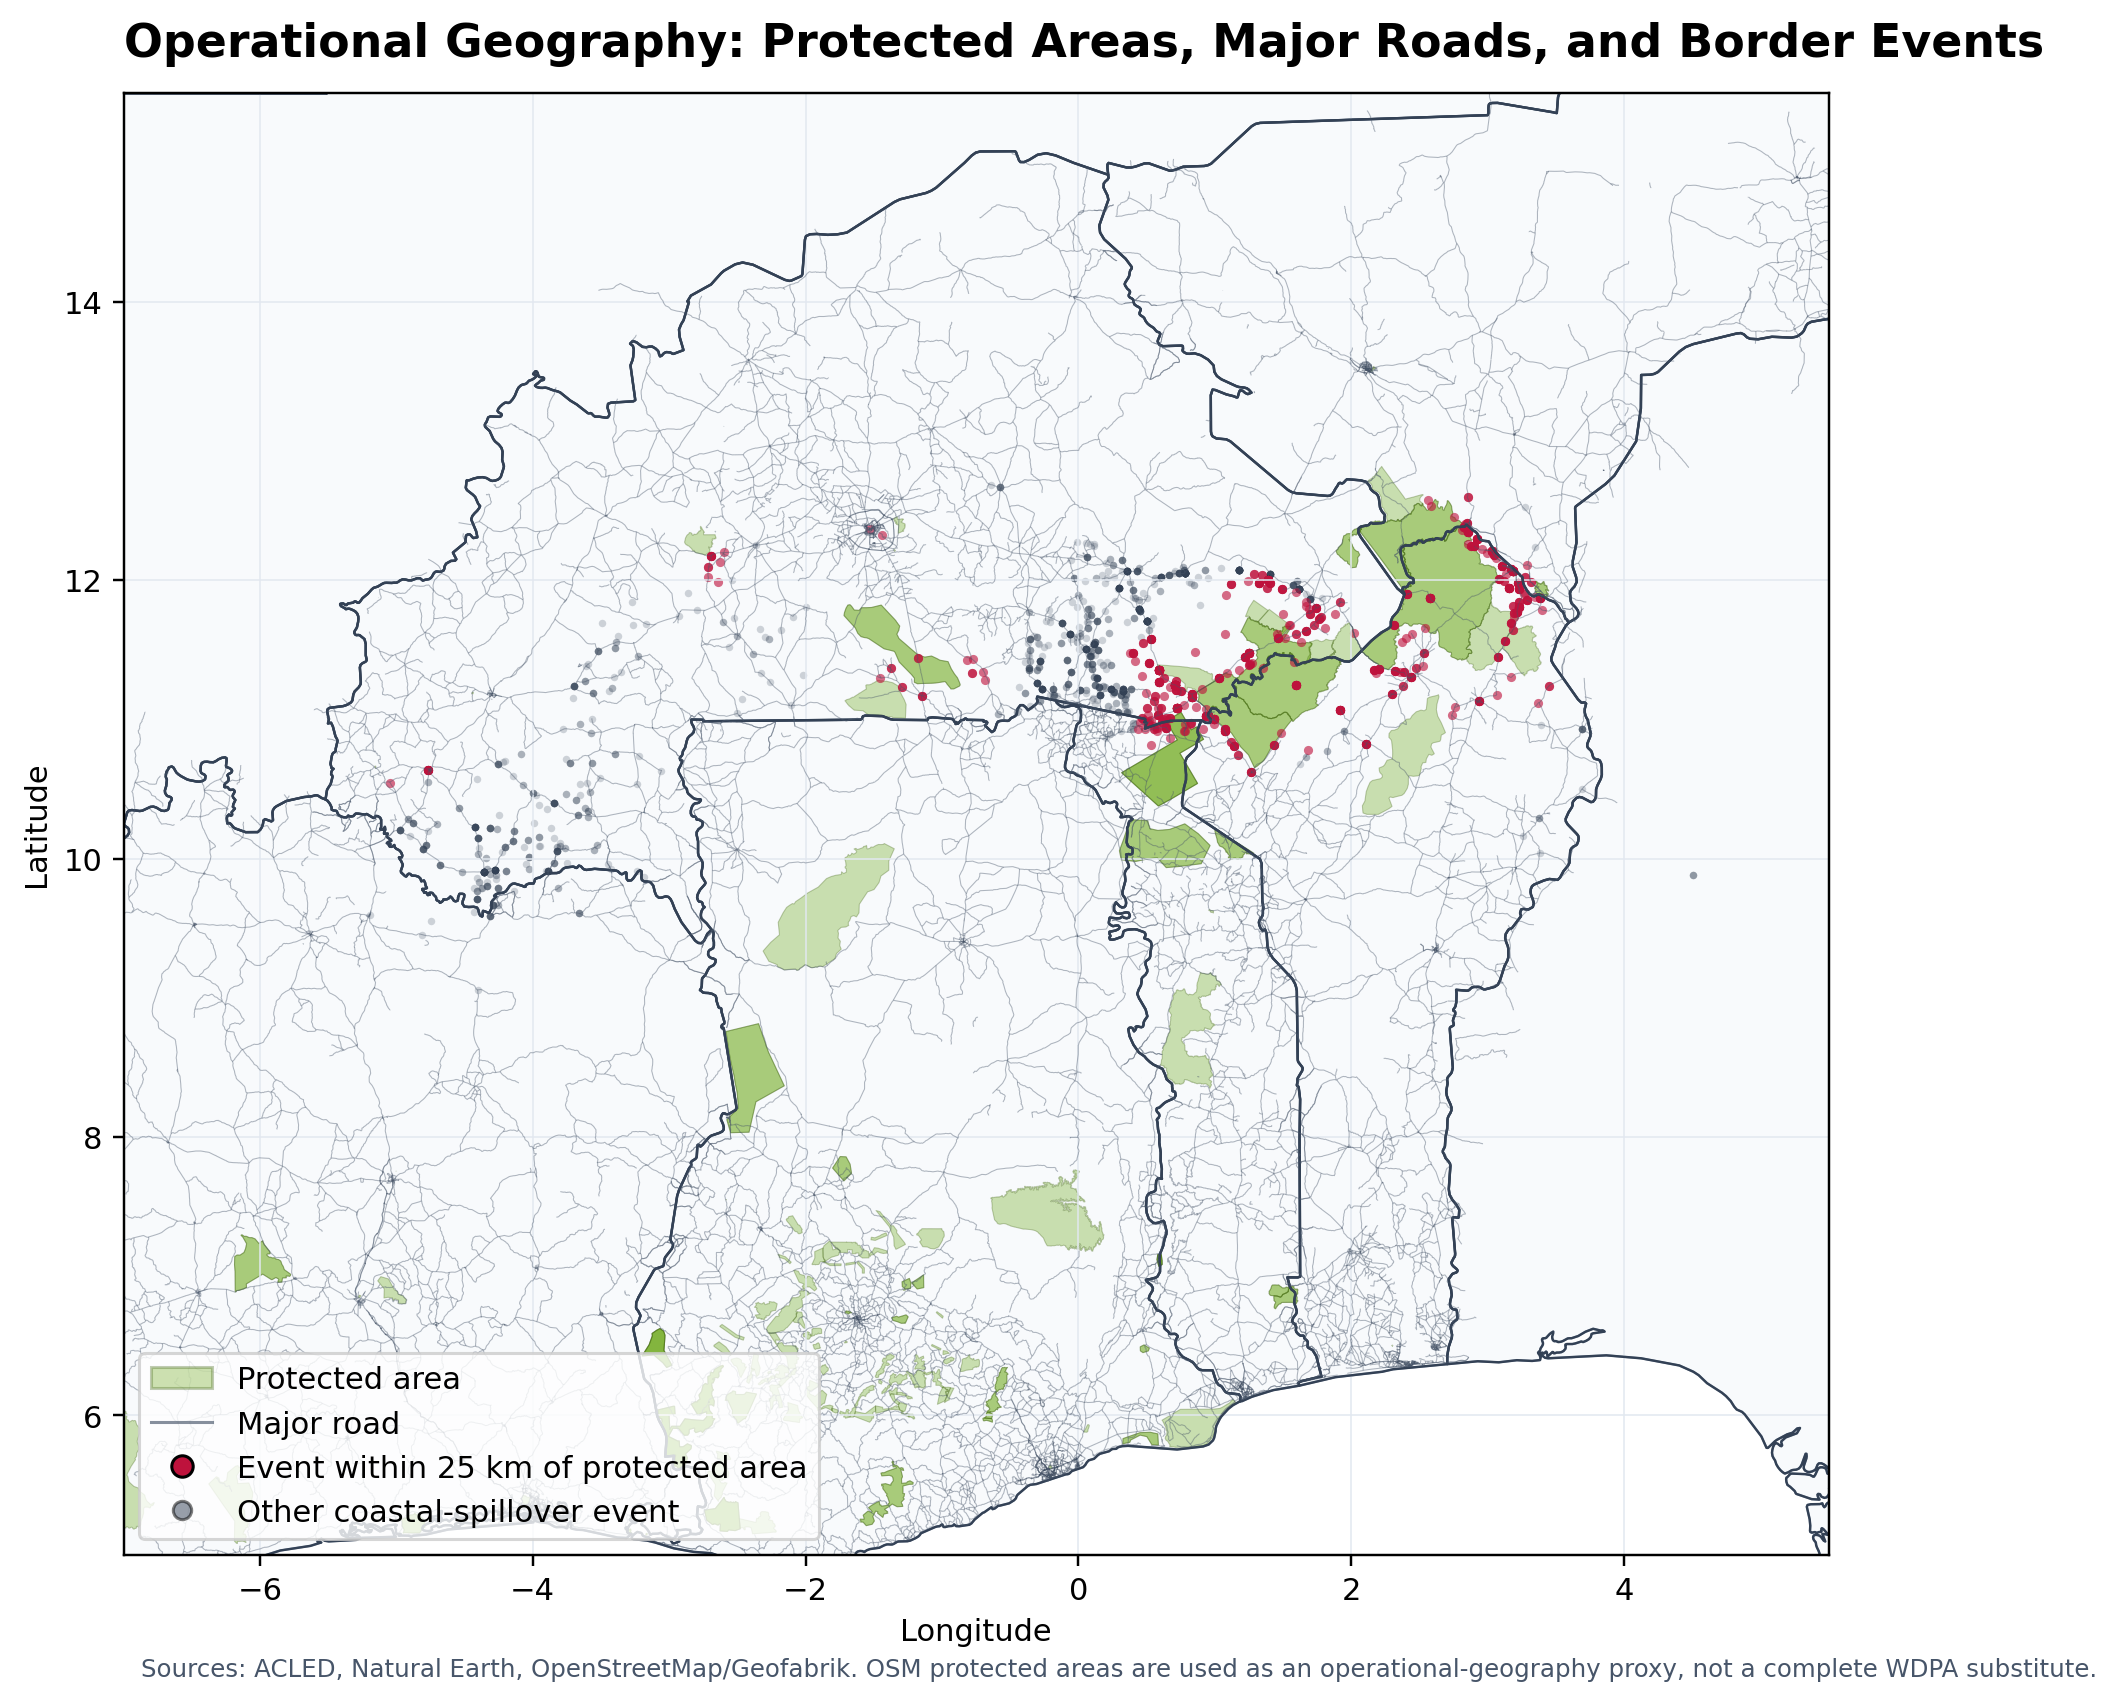

In [6]:
from IPython.display import Image, display
display(Image('outputs/maps/west_africa_operational_geography.png'));

**Interpretation.** The protected-area layer is especially informative around Benin-Niger and Benin-Burkina Faso, where events cluster near park and reserve areas. This supports the argument that some borderlands are not only politically peripheral, but operationally useful: they combine frontier jurisdictional gaps with terrain and land-use features that may complicate state presence and cross-border coordination.


## 4. Comparative Stress Test: Colombia-Venezuela

The Colombia-Venezuela section does not treat the border as a jihadist or terrorism case. Instead, it asks whether the same borderland exposure logic can help interpret a different armed ecosystem shaped by insurgency, organized crime, illicit economies, and fragmented state control.


In [ ]:
cv_bands = pd.read_csv(TABLES / 'colombia_venezuela_events_by_border_band.csv')
cv_bands['share_events'] = cv_bands['events'] / cv_bands['events'].sum()
cv_bands

In [ ]:
cv_index = pd.read_csv(TABLES / 'hybrid_border_violence_index_v1.csv')
cv_index[[
    'frontier_zone',
    'hybrid_border_violence_exposure_score',
    'risk_level',
    'evidence_confidence',
    'total_events',
    'recent_events',
    'actor_family_count',
]].head(10)

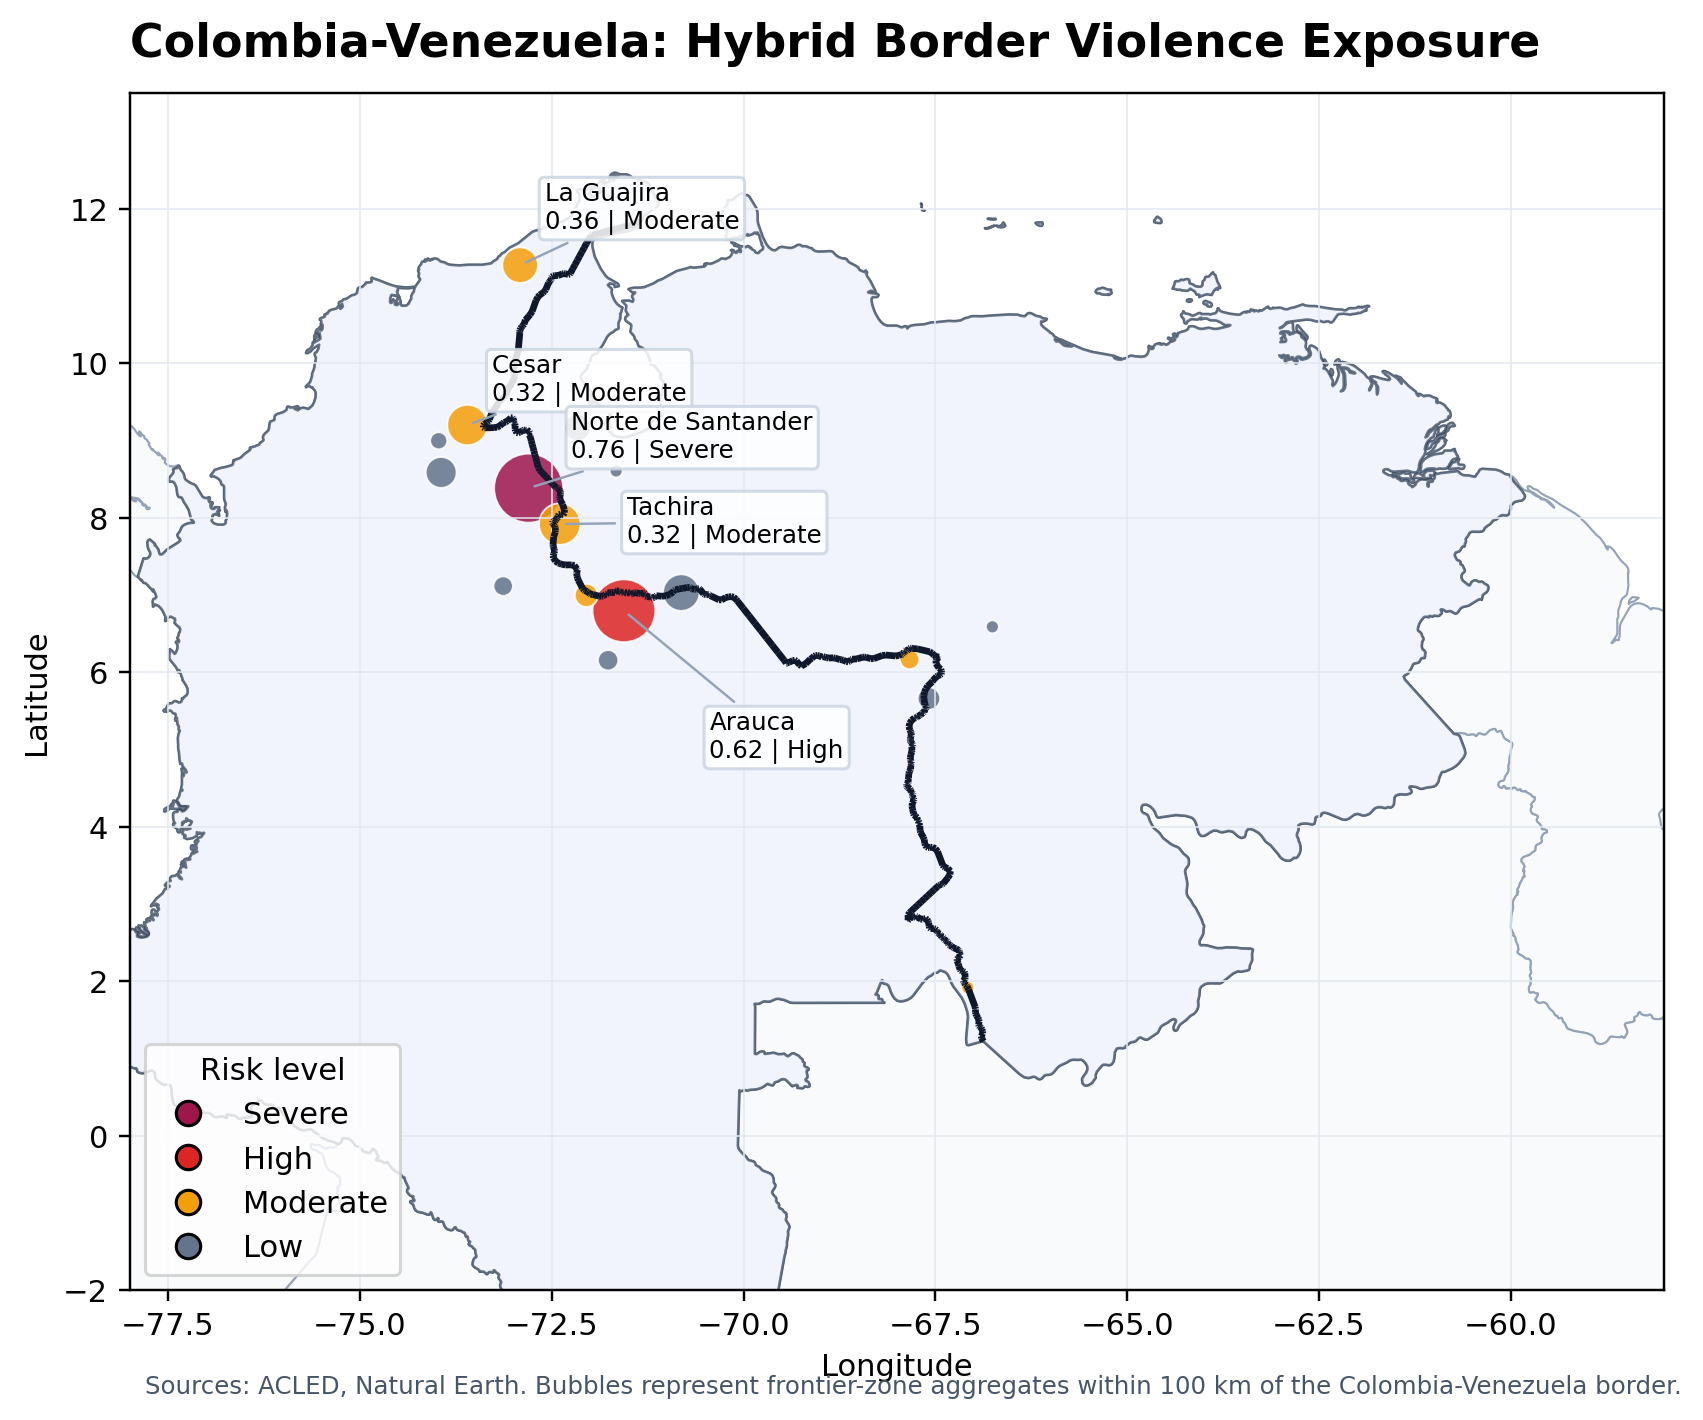

In [5]:
from IPython.display import Image, display
display(Image('outputs/maps/colombia_venezuela_hybrid_border_exposure.png'));

**Interpretation.** Norte de Santander and Arauca rank highest in the comparative index. The result is consistent with a borderland violence logic, but the mechanism is different from West Africa. Here, the relevant frame is hybrid armed governance rather than jihadist expansion: multiple armed groups, illicit economies, cross-border mobility, and contested state authority.


## 5. Limitations

- The indices are screening tools, not forecasts.
- ACLED coverage depends on source availability and reporting conditions.
- Actor classification is conservative and may miss ambiguous local naming patterns.
- OpenStreetMap coverage varies by country and region.
- Protected areas from Geofabrik are a proxy; a later version should compare results with WDPA.
- Road proximity should be interpreted cautiously because event locations are often coded to named settlements.
- The Colombia-Venezuela case is not treated as terrorism; it is a comparative borderland violence case.


## Conclusion

In summary, this project identifies spillover risk through a combination of indicators that capture both violence patterns and the geography that may enable armed groups to move, hide, or expand. The first indicators are recent violence, fatalities, and escalation over time, because a border zone where attacks are increasing is more relevant for risk monitoring than one where violence is only historical. Border proximity is included because the project is specifically interested in cross-border operational environments. The index also measures whether activity is appearing on the coastal-state side of the border, since this is one of the clearest signs that violence is moving beyond its original Sahelian core.

Applied to West Africa, these indicators are not distributed evenly across frontier zones. Benin-Niger produces the strongest coastal spillover signal, combining recent event volume, border proximity, coastal-side activity, and a notable concentration of events near protected areas. Burkina Faso-Togo ranks high on recent violence and border proximity. Benin-Burkina Faso sits in the moderate range but shows high evidence confidence and a stronger protected-area signal than most other coastal-facing dyads, which suggests that operational geography may be a leading indicator there even where overall event counts are lower. The Colombia-Venezuela comparison shows that the same spatial logic can travel beyond the jihadist context, but Norte de Santander and Arauca score high for different reasons: hybrid armed governance, illicit economies, and cross-border mobility rather than expansion from a Sahelian core.

Operational geography indicators are included alongside violence ones: proximity to protected areas and major road corridors. Protected areas are used as a proxy for remote or weakly governed terrain that may offer concealment, mobility, and refuge. Road proximity is included because armed groups need access to routes for movement, raids, supply, and expansion, although it is interpreted carefully because many ACLED events are coded near towns, which are often close to roads. Together, these indicators makes the tool useful to  compare frontier zones, distinguish entrenched violence from emerging spillover, and identify which border areas deserve closer monitoring.